# INTRODUCTION

General exploration of the data that we are using

In [1]:
import os

In [2]:
# Count the number of files in a directory
def count_files_in_directory(directory):
    try:
        return len([name for name in os.listdir(directory) if os.path.isfile(os.path.join(directory, name))])
    except FileNotFoundError:
        print(f"Directory {directory} not found.")
        return 0

# Example usage
if __name__ == "__main__":
    directory_path = "../data/image50/8863/0"
    file_count = count_files_in_directory(directory_path)
    print(f"Number of files in '{directory_path}': {file_count}")

Number of files in '../data/image50/8863/0': 772


In [3]:
# Count the number of folders in a directory
def count_folders_in_directory(directory):
    try:
        return len([name for name in os.listdir(directory) if os.path.isdir(os.path.join(directory, name))])
    except FileNotFoundError:
        print(f"Directory {directory} not found.")
        return 0

# Example usage
if __name__ == "__main__":
    directory_path = "../data/image50/"
    folder_count = count_folders_in_directory(directory_path)
    print(f"Number of folders in '{directory_path}': {folder_count}")

Number of folders in '../data/image50/': 279


In [4]:
import os
import random
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Base directory
base_path = '../data/image50/'

# Collect all image paths recursively in 0/ and 1/
all_images = []
for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.lower().endswith((".png", ".jpg", ".jpeg")):
            all_images.append(os.path.join(root, file))

print(f"Total images found: {len(all_images)}")

# Randomly sample 1000
sample_size = 10000
sampled_images = random.sample(all_images, min(sample_size, len(all_images)))

# Initialize histograms
r_hist = np.zeros(256)
g_hist = np.zeros(256)
b_hist = np.zeros(256)

# Populate histograms
for img_path in tqdm(sampled_images):
    img = Image.open(img_path).convert("RGB")
    r, g, b = np.array(img).transpose(2, 0, 1)

    r_hist += np.histogram(r, bins=256, range=(0, 255))[0]
    g_hist += np.histogram(g, bins=256, range=(0, 255))[0]
    b_hist += np.histogram(b, bins=256, range=(0, 255))[0]

Total images found: 277524


100%|██████████| 10000/10000 [00:29<00:00, 339.72it/s]


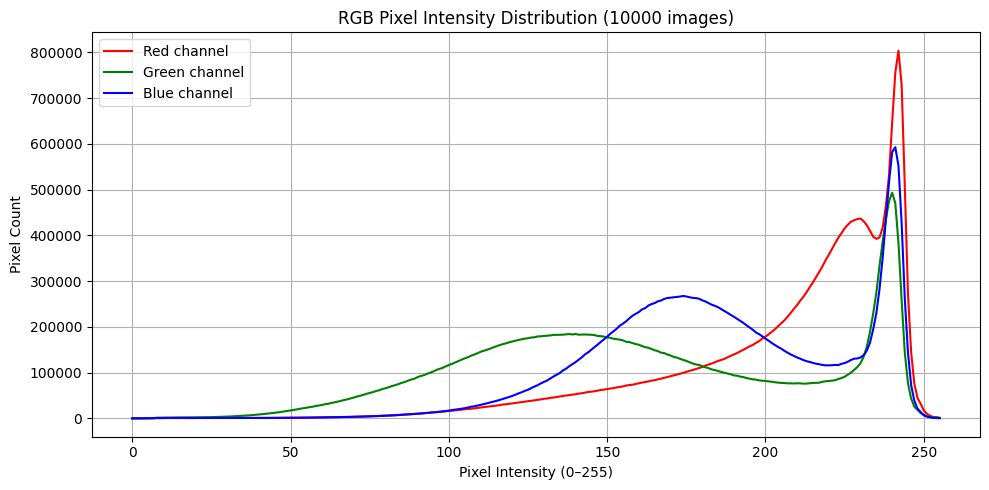

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(r_hist, color='red', label='Red channel')
plt.plot(g_hist, color='green', label='Green channel')
plt.plot(b_hist, color='blue', label='Blue channel')
plt.title("RGB Pixel Intensity Distribution (10000 images)")
plt.xlabel("Pixel Intensity (0–255)")
plt.ylabel("Pixel Count")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [6]:
all_images = []
for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.lower().endswith((".png", ".jpg", ".jpeg")):
            all_images.append(os.path.join(root, file))

print(f"Total images found: {len(all_images)}")

sample_size = 10000
sampled_images = random.sample(all_images, min(sample_size, len(all_images)))

# Store contrast values (std of grayscale)
contrast_values = []

for img_path in tqdm(sampled_images):
    img = Image.open(img_path).convert("L")  # convert to grayscale
    pixels = np.array(img).astype(np.float32)
    std_dev = pixels.std()  # simple contrast metric
    contrast_values.append(std_dev)


Total images found: 277524


100%|██████████| 10000/10000 [00:19<00:00, 524.83it/s]


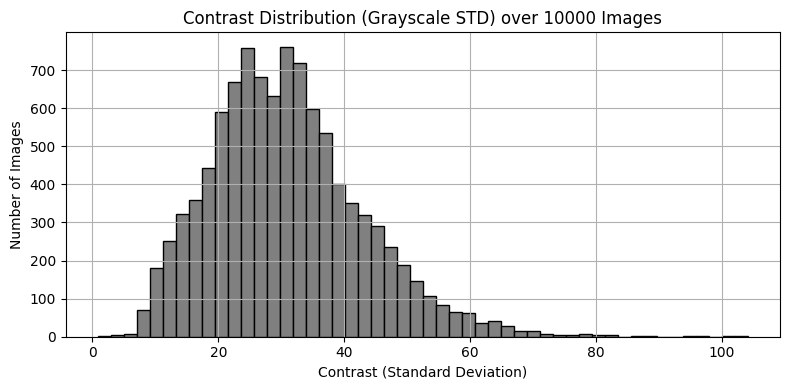

In [7]:
plt.figure(figsize=(8, 4))
plt.hist(contrast_values, bins=50, color='gray', edgecolor='black')
plt.title(f"Contrast Distribution (Grayscale STD) over {sample_size} Images")
plt.xlabel("Contrast (Standard Deviation)")
plt.ylabel("Number of Images")
plt.grid(True)
plt.tight_layout()
plt.show()


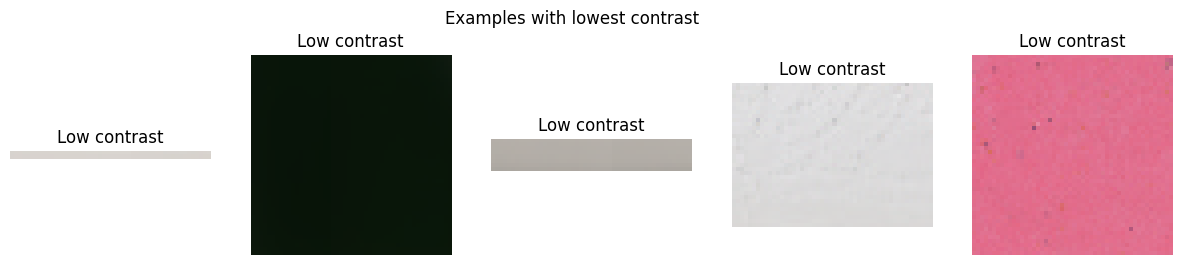

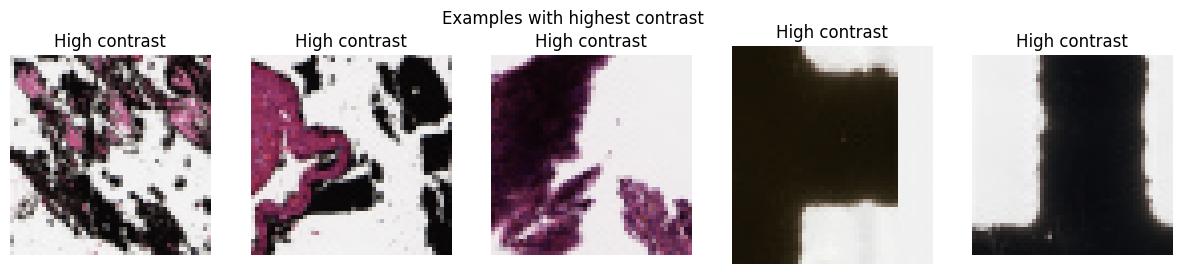

In [8]:
# Sort image paths by contrast
sorted_pairs = sorted(zip(sampled_images, contrast_values), key=lambda x: x[1])

# Show 5 lowest contrast images
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, (img_path, _) in enumerate(sorted_pairs[:5]):
    img = Image.open(img_path).convert("RGB")
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title("Low contrast")
plt.suptitle("Examples with lowest contrast")
plt.show()

# Show 5 highest contrast images
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, (img_path, _) in enumerate(sorted_pairs[-5:]):
    img = Image.open(img_path).convert("RGB")
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title("High contrast")
plt.suptitle("Examples with highest contrast")
plt.show()


In [10]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm

# Count the number of images that do not have the shape 50*50
def count_invalid_images(directory, target_shape=(50, 50)):
    # Get all image paths
    all_images = []
    for root, dirs, files in os.walk(directory):
        for file in files:
            if file.lower().endswith((".png", ".jpg", ".jpeg")):
                all_images.append(os.path.join(root, file))
    
    print(f"Found {len(all_images)} images. Checking shapes...")
    
    # Function to check if an image has the target shape
    def check_image_shape(img_path):
        try:
            img = Image.open(img_path)
            return img.size != target_shape
        except Exception as e:
            print(f"Error processing {img_path}: {e}")
            return False
    
    # Number of threads (adjust based on your CPU)
    num_workers = os.cpu_count() or 4
    
    # Count invalid images in parallel
    invalid_count = 0
    with ThreadPoolExecutor(max_workers=num_workers) as executor:
        futures = [executor.submit(check_image_shape, path) for path in all_images]
        for future in tqdm(as_completed(futures), total=len(futures)):
            if future.result():
                invalid_count += 1
    
    return invalid_count

if __name__ == "__main__":
    directory_path = "../data/image50/"
    invalid_image_count = count_invalid_images(directory_path)
    print(f"Number of images not in shape {50}x{50}: {invalid_image_count}")

Found 277524 images. Checking shapes...


100%|██████████| 277524/277524 [02:18<00:00, 2006.11it/s]


Number of images not in shape 50x50: 2302


### Trying to normalize the contrast

In [14]:
import cv2

In [15]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
gray = cv2.imread("../data/image50/8863/0/8863_idx5_x51_y1251_class0.png", 0)
clahe_img = clahe.apply(gray)

In [17]:
def apply_clahe_rgb(img_bgr):
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_clahe = clahe.apply(l)

    lab_clahe = cv2.merge((l_clahe, a, b))
    result_bgr = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2BGR)
    return result_bgr

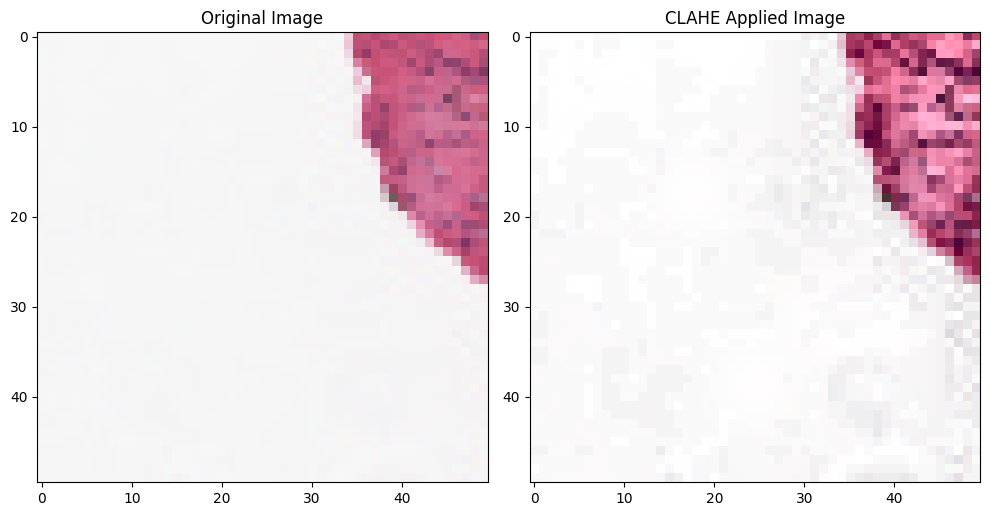

In [22]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(cv2.imread("../data/image50/8863/0/8863_idx5_x51_y1251_class0.png"), cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(apply_clahe_rgb(cv2.imread("../data/image50/8863/0/8863_idx5_x51_y1251_class0.png")), cv2.COLOR_BGR2RGB))
plt.title("CLAHE Applied Image")
plt.tight_layout()
plt.show()

In [23]:
import os
import cv2
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

src_root = '../data/image50'
# Destination (processed) dataset
dst_root = '../data/image50_clahe'

def apply_clahe_rgb(img_bgr):
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_clahe = clahe.apply(l)
    lab_clahe = cv2.merge((l_clahe, a, b))
    return cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2BGR)

def process_image(src_dst):
    src_path, dst_path = src_dst
    try:
        img = cv2.imread(src_path)
        if img is None:
            return False
        img_clahe = apply_clahe_rgb(img)
        os.makedirs(os.path.dirname(dst_path), exist_ok=True)
        cv2.imwrite(dst_path, img_clahe)
        return True
    except:
        return False

# Récupère tous les chemins
all_images = []
for root, _, files in os.walk(src_root):
    for file in files:
        if file.lower().endswith((".png", ".jpg", ".jpeg")):
            src_path = os.path.join(root, file)
            rel_path = os.path.relpath(src_path, src_root)
            dst_path = os.path.join(dst_root, rel_path)
            all_images.append((src_path, dst_path))

print(f"Total images: {len(all_images)}")

# Nombre de threads (tu peux adapter)
num_workers = os.cpu_count() or 4

# Exécution parallèle
with ThreadPoolExecutor(max_workers=num_workers) as executor:
    futures = [executor.submit(process_image, pair) for pair in all_images]
    for _ in tqdm(as_completed(futures), total=len(futures)):
        pass


Total images: 277524


100%|██████████| 277524/277524 [04:39<00:00, 994.03it/s] 


In [26]:
class PairedImageDataset():
    def __init__(self, src_root, dst_root, transform=None):
        self.src_root = src_root
        self.dst_root = dst_root
        self.transform = transform
        self.image_pairs = []

        for root, _, files in os.walk(src_root):
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    src_path = os.path.join(root, file)
                    rel_path = os.path.relpath(src_path, src_root)
                    dst_path = os.path.join(dst_root, rel_path)
                    if os.path.exists(dst_path):
                        self.image_pairs.append((src_path, dst_path))

    def __len__(self):
        return len(self.image_pairs)

    def __getitem__(self, idx):
        src_path, dst_path = self.image_pairs[idx]
        img_orig = Image.open(src_path).convert("RGB")
        img_clahe = Image.open(dst_path).convert("RGB")

        if self.transform:
            img_orig = self.transform(img_orig)
            img_clahe = self.transform(img_clahe)

        return img_orig, img_clahe

In [27]:
from torch.utils.data import DataLoader
from torchvision import transforms

# Define any transforms (resize, tensor conversion, etc.)
transform = transforms.Compose([
    transforms.Resize((100, 100)),  # or your image size
    transforms.ToTensor()
])

dataset = PairedImageDataset(
    src_root='../data/image50',
    dst_root='../data/image50_clahe',
    transform=transform
)

loader = DataLoader(dataset, batch_size=5, shuffle=True)


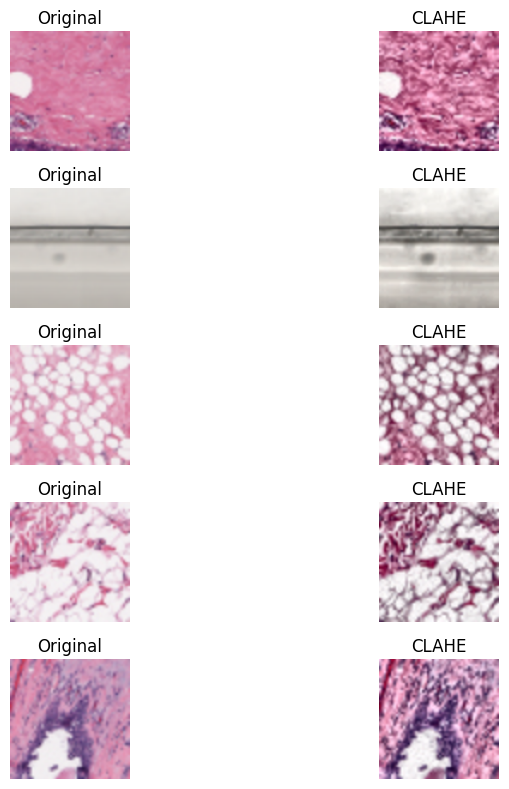

In [28]:
import matplotlib.pyplot as plt

# Get a batch of 5 pairs
orig_images, clahe_images = next(iter(loader))

# Plot
plt.figure(figsize=(10, 8))

for i in range(5):
    # Original
    plt.subplot(5, 2, i*2 + 1)
    plt.imshow(orig_images[i].permute(1, 2, 0))
    plt.title("Original")
    plt.axis("off")

    # CLAHE
    plt.subplot(5, 2, i*2 + 2)
    plt.imshow(clahe_images[i].permute(1, 2, 0))
    plt.title("CLAHE")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [41]:
# Zipping the processed dataset
import zipfile
# Dossier à compresser
dst_root = '../data/image50_clahe'
# Fichier de sortie
zip_filename = '../data/image50_clahe.zip'

def zip_folder(folder_path, zip_path):
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, _, files in os.walk(folder_path):
            for file in files:
                file_path = os.path.join(root, file)
                # Conserve le chemin relatif dans le zip
                rel_path = os.path.relpath(file_path, folder_path)
                zipf.write(file_path, arcname=rel_path)

zip_folder(dst_root, zip_filename)
print(f"Dossier compressé dans : {zip_filename}")


KeyboardInterrupt: 